# Analíticas de Idealista Scraper
Este notebook te permite analizar los resultados guardados en los archivos CSV.
Ejecuta las celdas paso a paso. Los gráficos se mostrarán aquí y también se guardarán en una carpeta con el mismo nombre del CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#  ESCANEAR ARCHIVOS CSV EN LA CARPETA DATA
data_dir = "../output"
all_files = []
if os.path.exists(data_dir):
    for root_dir, dirs, files in os.walk(data_dir):
        for file in files:
            if file.endswith(".csv"):
                all_files.append(os.path.join(root_dir, file))
# Crear listas dinámicas de archivos de Rent y Buy
rent_files = sorted([f for f in all_files if "_rent_" in f.lower() or "\\rent_" in f.lower() or "/rent_" in f.lower()])
buy_files = sorted([f for f in all_files if "_buy_" in f.lower() or "\\buy_" in f.lower() or "/buy_" in f.lower()])
rent_txt = "\n".join([f"  [{i}] {os.path.relpath(f, data_dir)}" for i, f in enumerate(rent_files)])
buy_txt = "\n".join([f"  [{i}] {os.path.relpath(f, data_dir)}" for i, f in enumerate(buy_files)])
print(f"--- ARCHIVOS DE ALQUILER (Rent) ENCONTRADOS ---\nTotal: {len(rent_files)}\n{rent_txt}")
print(f"\n--- ARCHIVOS DE COMPRA (Buy) ENCONTRADOS ---\nTotal: {len(buy_files)}\n{buy_txt}")

--- ARCHIVOS DE ALQUILER (Rent) ENCONTRADOS ---
Total: 0


--- ARCHIVOS DE COMPRA (Buy) ENCONTRADOS ---
Total: 20
  [0] 100000-220000_buy_used_Ali_afueras\Ali_afueras.csv
  [1] 100000-240000_buy_used_Bcn_afueras\Bcn_afueras.csv
  [2] 100000-260000_buy_used_Bcn_dentro\Bcn_dentro.csv
  [3] 110000-170000_buy_used_Ali_dentro\Ali_dentro.csv
  [4] 110000-190000_buy_used_Sev_fuera\Sev_fuera.csv
  [5] 110000-230000_buy_used_Sev_dentro\Sev_dentro.csv
  [6] 110000-270000_buy_used_Mal_dentro\Mal_dentro.csv
  [7] 110000-280000_buy_used_Mal_afueras\Mal_afueras.csv
  [8] 110000-320000_buy_new_Alic_afueras\Alic_afueras.csv
  [9] 110000-320000_buy_new_Alic_dentro\Alic_dentro.csv
  [10] 110000-320000_buy_new_Bcn_afueras\Bcn_afueras.csv
  [11] 110000-320000_buy_new_Bcn_dentro\Bcn_dentro.csv
  [12] 110000-320000_buy_new_Mal_afueras\Mal_afueras.csv
  [13] 110000-320000_buy_new_Mal_dentro\Mal_dentro.csv
  [14] 110000-320000_buy_new_Sev_afueras\Sev_afueras.csv
  [15] 110000-320000_buy_new_Sev_dentro\Sev_den

In [4]:
CSV_FILENAME = buy_files[1]
base_name = os.path.splitext(os.path.basename(CSV_FILENAME))[0]
OUTPUT_DIR = os.path.dirname(CSV_FILENAME)
print(f"\n--- CONFIGURACIÓN DE SALIDA ---\n\nGráficos en: {OUTPUT_DIR}\n\nArchivo seleccionado: {os.path.basename(CSV_FILENAME)}")


--- CONFIGURACIÓN DE SALIDA ---

Gráficos en: ../output\100000-240000_buy_used_Bcn_afueras

Archivo seleccionado: Bcn_afueras.csv


In [5]:
#  CARGAR Y LIMPIAR DATOS
df = pd.read_csv(CSV_FILENAME, dtype=str)
pd.set_option('display.max_colwidth', None)
# Detectar si es Rent o Buy a partir del nombre del archivo CSV.
is_rent = '_rent_' in base_name.lower()
is_buy = '_buy_' in base_name.lower()
modo = "ALQUILER (Rent)" if is_rent else "COMPRA (Buy)"
print(f"Modo detectado: {modo}")
# Convertir Precio, Área y Habitaciones de forma condensada
df['Price (€)'] = pd.to_numeric(df['Price (€)'], errors='coerce')
if 'Area (m²)' in df.columns:
    df['Area (m²)'] = pd.to_numeric(df['Area (m²)'].astype(str).str.replace('m²', '', regex=False).str.replace('.', '', regex=False).str.strip(), errors='coerce')
if 'Hab' in df.columns:
    df['Hab'] = pd.to_numeric(df['Hab'].astype(str).str.replace('hab.', '', regex=False).str.strip(), errors='coerce')
# Para terrenos (land), rellenamos Hab con 1 para evitar que se descarte la fila al limpiar nulos
if '_land_' in base_name.lower() and 'Hab' in df.columns:
    df['Hab'] = df['Hab'].fillna(1)
# Identificar TODAS las filas que serán descartadas (Nulos, precio excesivo, o muy pequeñas)
discard_mask = df.isnull().any(axis=1)
max_precio, min_space = 320000,65
if 'Price (€)' in df.columns:
    discard_mask = discard_mask | (df['Price (€)'] > max_precio)
if 'Area (m²)' in df.columns:
    discard_mask = discard_mask | (df['Area (m²)'] < min_space)
discarded_rows = df[discard_mask].sort_values(by=['Hab', 'Area (m²)', 'Price (€)'], ascending=[True, True, True])
if not discarded_rows.empty:
    print(f"--- FILAS DESCARTADAS (Nulos, Precio > 320k, o Área < 65m²) ---\nTotal descartadas: {len(discarded_rows)}")
    display(discarded_rows)
else:
    print("--- NO SE DETECTARON FILAS BASURA (Todo limpio) ---")
# Descartar las filas identificadas y resetear índice
df = df[~discard_mask].reset_index(drop=True)
# Calcular Precio Unitario según el modo (Venta -> Price/SqM | Alquiler -> Price/room)
if is_rent and 'Hab' in df.columns:
    df['Price/room'] = (df['Price (€)'] / df['Hab'].replace(0, np.nan)).round(0).astype('Int64')
elif not is_rent and 'Area (m²)' in df.columns:
    df['Price/SqM'] = (df['Price (€)'] / df['Area (m²)']).round(0).astype('Int64')
print(f"Total de propiedades limpias cargadas: {len(df)}")
print("\n--- PRIMERAS FILAS DEL DATASET (df.head) ---")
display(df.head())
print("\n--- ÚLTIMAS FILAS DEL DATASET (df.tail) ---")
display(df.tail())
print(f"\n--- TIPOS DE DATOS DE LAS COLUMNAS ---\n{df.dtypes}")
print("\n--- ESTADÍSTICAS DESCRIPTIVAS GENERALES ---")
display(df.describe().apply(lambda s: s.apply('{0:.0f}'.format)))

Modo detectado: COMPRA (Buy)
--- NO SE DETECTARON FILAS BASURA (Todo limpio) ---
Total de propiedades limpias cargadas: 143

--- PRIMERAS FILAS DEL DATASET (df.head) ---


,Link,Price (€),Area (m²),Hab,Location,Price/SqM
0,https://www.idealista.com/inmueble/111239342/,103300,86,3,"Espronceda, Sabadell",1201
1,https://www.idealista.com/inmueble/110674240/,119000,87,4,"Espronceda, Sabadell",1368
2,https://www.idealista.com/inmueble/109492595/,120500,92,4,"Espronceda, Sabadell",1310
3,https://www.idealista.com/inmueble/111196103/,130000,80,2,"Centre, Santa Coloma de Gramenet",1625
4,https://www.idealista.com/inmueble/109192260/,132000,108,3,"Creu de Barberà, Sabadell",1222



--- ÚLTIMAS FILAS DEL DATASET (df.tail) ---


,Link,Price (€),Area (m²),Hab,Location,Price/SqM
138,https://www.idealista.com/inmueble/111806698/,240000,98,3,"Mas Rampinyo - Carrerada, Montcada i Reixac",2449
139,https://www.idealista.com/inmueble/110104760/,240000,80,3,Sant Boi de Llobregat,3000
140,https://www.idealista.com/inmueble/111499774/,240000,93,4,"Les Termes, Sabadell",2581
141,https://www.idealista.com/inmueble/111396961/,240000,88,2,"Centre, Badalona",2727
142,https://www.idealista.com/inmueble/110292151/,240000,101,3,"Sant Andreu, Barcelona",2376



--- TIPOS DE DATOS DE LAS COLUMNAS ---
Link         object
Price (€)     int64
Area (m²)     int64
Hab           int64
Location     object
Price/SqM     Int64
dtype: object

--- ESTADÍSTICAS DESCRIPTIVAS GENERALES ---


,Price (€),Area (m²),Hab,Price/SqM
count,143,143,143,143
mean,207676,92,3,2290
std,29487,12,1,397
min,103300,80,2,1201
25%,193950,84,3,2033
50%,214800,89,3,2314
75%,230000,96,3,2593
max,240000,136,4,3000


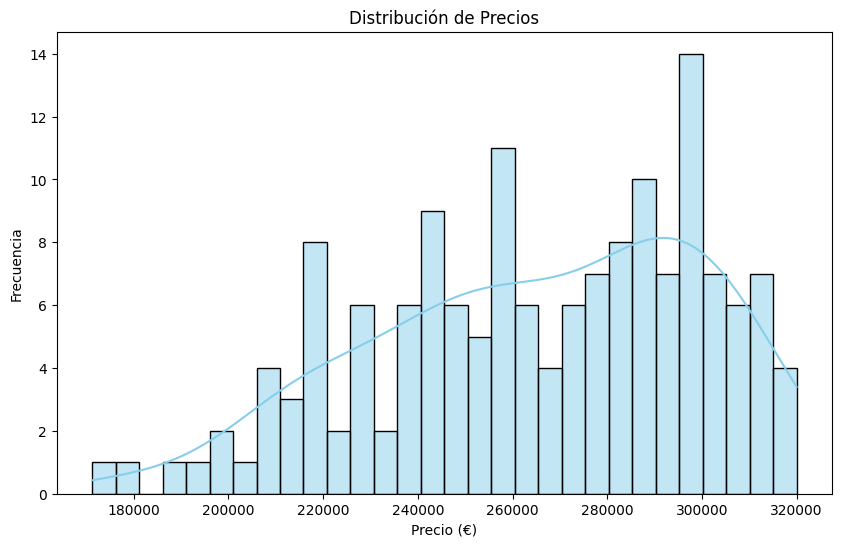

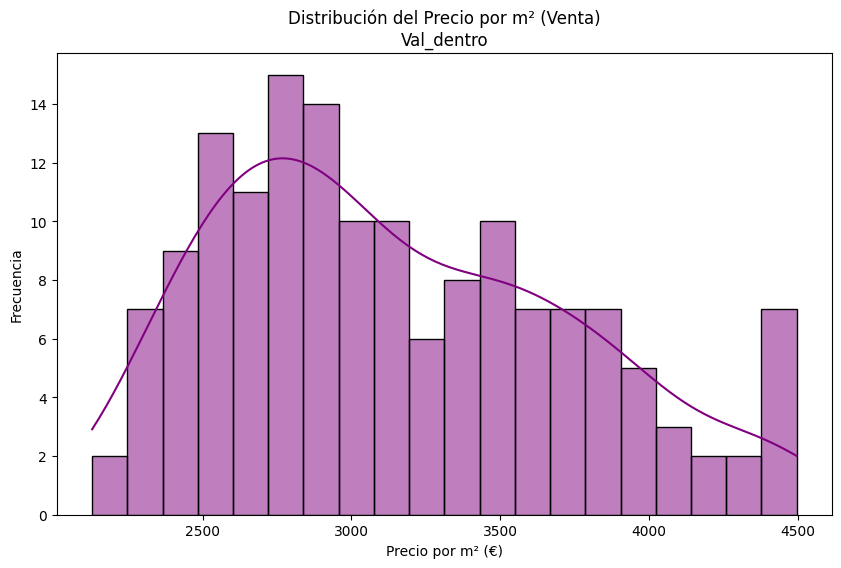

In [4]:
# 4. HISTOGRAMAS DE DISTRIBUCIÓN
# Histograma de Precios
plt.figure(figsize=(10, 6))
sns.histplot(df['Price (€)'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Distribución de Precios')
plt.xlabel('Precio (€)')
plt.ylabel('Frecuencia')
plt.savefig(os.path.join(OUTPUT_DIR, 'distribucion_precios.png'), bbox_inches='tight')
plt.show()

# Histograma de Precio Unitario (Precio por Habitación en Rent o por m² en Buy)
plt.figure(figsize=(10, 6))
if is_rent:
    sns.histplot(df['Price/room'].dropna(), kde=True, bins=20, color='lightgreen')
    plt.title(f'Distribución del Precio por Habitación (Alquiler)\n{base_name}')
    plt.xlabel('Precio por Habitación (€/mes)')
    filename = 'rent_price_room_dist.png'
else:
    sns.histplot(df['Price/SqM'].dropna(), kde=True, bins=20, color='purple')
    plt.title(f'Distribución del Precio por m² (Venta)\n{base_name}')
    plt.xlabel('Precio por m² (€)')
    filename = 'buy_price_sqm_dist.png'
plt.ylabel('Frecuencia')
plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches='tight')
plt.show()

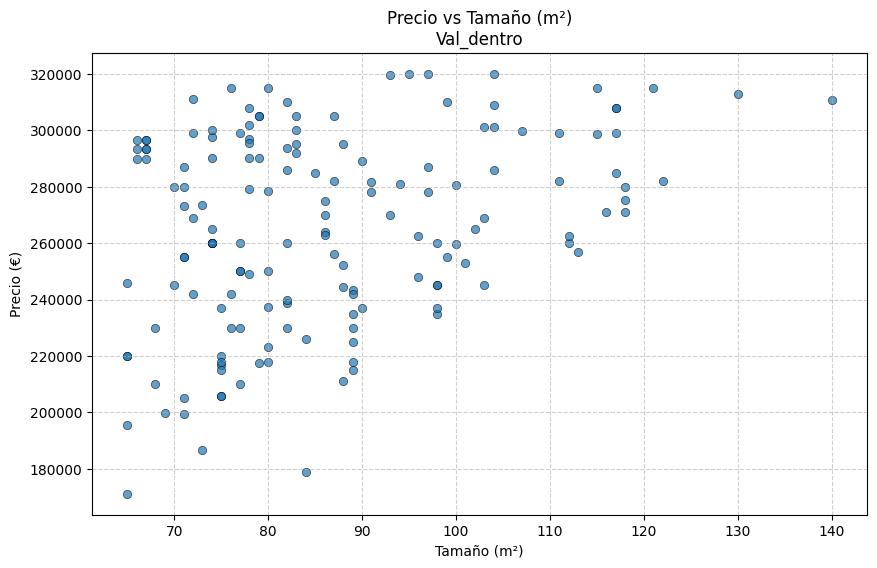

In [5]:
# 5. RELACIÓN PRECIO VS TAMAÑO (SCATTER PLOT)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Area (m²)', y='Price (€)', alpha=0.7, edgecolor='k')
plt.title(f'Precio vs Tamaño (m²)\n{base_name}')
plt.xlabel('Tamaño (m²)')
plt.ylabel('Precio (€)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join(OUTPUT_DIR, 'precio_vs_tamano.png'), bbox_inches='tight')
plt.show()

In [ ]:
""" 
# 6. ANÁLISIS POR UBICACIÓN (BOXPLOTS POR ZONAS)
# Obtener todas las ubicaciones únicas ordenadas por cantidad de propiedades
locations = df['Location'].value_counts().index.tolist()
locs_per_plot = 10

# Dividir las ubicaciones en grupos legibles
for i in range(0, len(locations), locs_per_plot):
    group_locs = locations[i:i+locs_per_plot]
    df_group = df[df['Location'].isin(group_locs)]
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_group, x='Location', y='Price (€)')
    plt.title(f'Dispersión de Precios por Ubicación - Grupo {i//locs_per_plot + 1}')
    plt.xticks(rotation=45, ha='right')
    
    # Guardar y mostrar cada grupo
    filename = f'boxplot_ubicaciones_grupo_{i//locs_per_plot + 1}.png'
    plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches='tight')
    plt.show()
    """

In [ ]:
"""# 8. CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
cols = [c for c in ['Price (€)', 'Area (m²)', 'Hab', 'Price/room' if is_rent else 'Price/SqM'] if c in df.columns]
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre Variables', fontsize=16)
plt.savefig(os.path.join(OUTPUT_DIR, 'correlacion.png'), bbox_inches='tight')
plt.show()"""

## Filtrado de Inmuebles

Definición de funciones de filtrado personalizadas según las reglas del script original (asumiendo columnas completas).

In [6]:
# 9. FUNCIONES DE FILTRADO DE PROPIEDADES (USO PERSONAL)
def filter_rent_rows(df, mx_pr_1h=1200, mx_pr_room=800, min_area_1h=60, min_area_2h=75, min_area_3h=100, include=None, exclude=None):
    """
    Filtra opciones de alquiler con tamaños mínimos aceptables según cantidad de habs.
    """
    c1 = (df['Hab'] == 1) & (df['Price (€)'] <= mx_pr_1h) & (df['Area (m²)'] >= min_area_1h)
    c2 = (df['Hab'] == 2) & (df['Price/room'] <= mx_pr_room) & (df['Area (m²)'] >= min_area_2h)
    c3 = (df['Hab'] >= 3) & (df['Price/room'] <= mx_pr_room) & (df['Area (m²)'] >= min_area_3h)
    res = df[c1 | c2 | c3]
    if exclude: res = res[~res['Location'].isin(exclude)]
    if include: res = res[res['Location'].isin(include)]
    return res.drop_duplicates().reset_index(drop=True)

def filter_buy_rows(df, min_h=2, min_price_sqm=1500, max_price_sqm=3000, min_area_any=60, min_area_large=100, min_hab_large=3, max_size=200, exclude=None):
    """
    Filtra opciones de compra acotando por precio/m2, descartando pisos muy grandes o muy chicos.
    Asegura que si un piso tiene muchas habitaciones, tenga el tamaño mínimo adecuado para no estar apretados.
    """
    cond = (df['Price/SqM'].between(min_price_sqm, max_price_sqm)) & (df['Area (m²)'].between(min_area_any, max_size)) & (df['Hab'] >= min_h)
    # Si tiene min_hab_large habitaciones o más, el área DEBE ser mayor o igual a min_area_large
    cond &= (df['Hab'] < min_hab_large) | (df['Area (m²)'] >= min_area_large)
    res = df[cond]
    if exclude: res = res[~res['Location'].isin(exclude)]
    return res.drop_duplicates().reset_index(drop=True)

In [8]:
# 10. EJECUTAR FILTRADO DE LA BÚSQUEDA (ALQUILER O COMPRA PERSONAL)
if is_rent:
    exclude_locations = []#['Terrassa', 'Mataró', 'Sabadell', 'Martorell', 'Sant Vicenç de Montalt', 'Cabrera de Mar']
    df_filtrado = filter_rent_rows(df, mx_pr_1h=1000, mx_pr_room=600, min_area_1h=60, min_area_2h=75, min_area_3h=95, exclude=exclude_locations).sort_values(['Hab', 'Area (m²)', 'Price (€)'])
    print(f"--- PROPIEDADES ENCONTRADAS PARA ALQUILER PERSONAL ---\nTotal aptas: {len(df_filtrado)}")
    display(df_filtrado)
else:
    df_filtrado = filter_buy_rows(df, min_h=2, min_price_sqm=1500, max_price_sqm=2900, min_area_any=65, min_area_large=90, min_hab_large=3, max_size=85).sort_values('Price/SqM')
    print(f"--- PROPIEDADES ENCONTRADAS PARA COMPRA PERSONAL ---\nTotal aptas: {len(df_filtrado)}")
    display(df_filtrado)

--- PROPIEDADES ENCONTRADAS PARA COMPRA PERSONAL ---
Total aptas: 9


,Location,Link,Price (€),Area (m²),Hab,Price/SqM
1,Alaquás,https://www.idealista.com/obra-nueva/109585063/inmueble/111189418/,186653,73,2.0,2557
0,"Centro Ciudad, Manises",https://www.idealista.com/obra-nueva/111498195/inmueble/111498841/,218000,80,2.0,2725
6,"La Torre, València",https://www.idealista.com/obra-nueva/106034746/inmueble/110628905/,210000,77,2.0,2727
3,"Centro Ciudad, Paterna",https://www.idealista.com/obra-nueva/110510581/inmueble/110514367/,206000,75,2.0,2747
4,"Centro Ciudad, Paterna",https://www.idealista.com/obra-nueva/111145138/inmueble/111149300/,206000,75,2.0,2747
7,"Centro Ciudad, Manises",https://www.idealista.com/obra-nueva/109788652/inmueble/109974973/,217700,79,2.0,2756
8,Almàssera,https://www.idealista.com/obra-nueva/106958190/inmueble/111786666/,223100,80,2.0,2789
5,"Centro Ciudad, Paterna",https://www.idealista.com/obra-nueva/111145138/inmueble/111149697/,230000,82,2.0,2805
2,"Centro Ciudad, Paterna",https://www.idealista.com/obra-nueva/110510581/inmueble/110514320/,199300,71,2.0,2807
